<a href="https://colab.research.google.com/github/Abhijith2005binu/AI-ML/blob/main/AI_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving marvel_master.csv to marvel_master (1).csv


In [ ]:
import os

print(os.listdir("/content"))


['.config', 'marvel_master.csv', 'sample_data']


In [ ]:
import pandas as pd

df = pd.read_csv("/content/marvel_master.csv")

df.head()

,id,title,year,imdb_id,type,rated,runtime_min,genre,director,writer,...,tmdb_keywords,collection_name,poster_url,production_countries,spoken_languages,episode_count,season_count,network,status,tagline
0,1,Captain America,1944,tt0036697,movie,Approved,244.0,"Action, Adventure, Sci-Fi","Elmer Clifton, John English","Royal K. Cole, Ronald Davidson, Basil Dickey",...,"superhero, based on comic, masked vigilante, m...",NaN,https://image.tmdb.org/t/p/w500/nBRcChS66NohR3...,United States of America,English,NaN,NaN,NaN,Released,NaN
1,2,The Amazing Spider-Man,1977,tt0076975,series,TV-PG,60.0,"Action, Adventure, Crime",NaN,NaN,...,"mind control, new york city, photographer, sec...",Spider-Man (TV) Collection,https://image.tmdb.org/t/p/w500/jNxRHZ2cxVkNRt...,United States of America,English,NaN,NaN,NaN,Released,The world's favorite adventure super hero in l...
2,3,Spider-Man,1977,tt0076975,series,TV-PG,60.0,"Action, Adventure, Crime",NaN,NaN,...,"mind control, new york city, photographer, sec...",Spider-Man (TV) Collection,https://image.tmdb.org/t/p/w500/jNxRHZ2cxVkNRt...,United States of America,English,NaN,NaN,NaN,Released,The world's favorite adventure super hero in l...
3,4,Dr. Strange,1978,tt0077469,movie,TV-PG,93.0,"Action, Fantasy",Philip DeGuere Jr.,"Philip DeGuere Jr., Steve Ditko, Stan Lee",...,based on comic,NaN,https://image.tmdb.org/t/p/w500/hEyHVgBE28Jl13...,United States of America,English,NaN,NaN,NaN,Released,Battle of the sorcerers burns the screen with ...
4,5,The Incredible Hulk,1978,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,based on comic,The Incredible Hulk Collection,https://image.tmdb.org/t/p/w500/3apbGlabEmgR1j...,United States of America,English,NaN,NaN,NaN,Released,She loved the man... would the beast destroy t...


In [ ]:
# Shape of the dataset
print("Rows and Columns:", df.shape)

# Dataset information
df.info()

# Column names
print(df.columns)

Rows and Columns: (161, 50)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 50 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    161 non-null    int64  
 1   title                 161 non-null    object 
 2   year                  161 non-null    int64  
 3   imdb_id               114 non-null    object 
 4   type                  114 non-null    object 
 5   rated                 101 non-null    object 
 6   runtime_min           97 non-null     float64
 7   genre                 113 non-null    object 
 8   director              94 non-null     object 
 9   writer                102 non-null    object 
 10  actors                109 non-null    object 
 11  plot                  108 non-null    object 
 12  language              113 non-null    object 
 13  country               113 non-null    object 
 14  awards                85 non-null     object 


In [ ]:
# First 5 records
df.head()
# Last 5 records
df.tail()
# Random 5 records
df.sample(5)

,id,title,year,imdb_id,type,rated,runtime_min,genre,director,writer,...,tmdb_keywords,collection_name,poster_url,production_countries,spoken_languages,episode_count,season_count,network,status,tagline
66,67,Ant-Man,2015,tt0478970,movie,PG-13,117.0,"Action, Comedy, Sci-Fi",Peyton Reed,"Edgar Wright, Joe Cornish, Adam McKay",...,"superhero, ant, master thief, shrinking, based...",Ant-Man Collection,https://image.tmdb.org/t/p/w500/rQRnQfUl3kfp78...,United States of America,English,NaN,NaN,NaN,Released,Heroes don't get any bigger.
87,88,The Punisher (Season 1),2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
83,84,The Defenders,2017,tt7551402,movie,NaN,NaN,"Short, Sci-Fi",Kevin Wendell,Kevin Wendell,...,"cold war, superhero, superhero team, soviet po...",NaN,https://image.tmdb.org/t/p/w500/sGHAoGdxD9CeJx...,"Russia, United States of America",Russian,NaN,NaN,NaN,Released,Squad of Soviet Superheroes
9,10,Captain America II: Death Too Soon,1979,tt0078938,movie,TV-PG,83.0,"Action, Adventure, Sci-Fi",Ivan Nagy,"Wilton Schiller, Patricia Payne, Jack Kirby",...,"superhero, based on comic",Captain America (Reb Brown) Collection,https://image.tmdb.org/t/p/w500/pocmh0P8Ddf5w3...,United States of America,English,NaN,NaN,NaN,Released,Sentinel of Liberty Returns
143,144,What If...?,2023,tt27056079,movie,NaN,NaN,"Short, Comedy",NaN,NaN,...,honeymoon,NaN,https://image.tmdb.org/t/p/w500/9dp0LlnahtNMwV...,Philippines,"English, Tagalog",NaN,NaN,NaN,Released,NaN


In [ ]:
df.isnull().sum()

,0
id,0
title,0
year,0
imdb_id,47
type,47
rated,60
runtime_min,64
genre,48
director,67
writer,59


In [ ]:
df.drop(
    ['production', 'website'],
    axis=1,
    inplace=True
)

In [ ]:
df.drop(
    ['episode_count', 'season_count', 'network'],
    axis=1,
    inplace=True
)

In [ ]:
num_cols = df.select_dtypes(
    include=['int64', 'float64']
).columns

for col in num_cols:
    df[col] = df[col].fillna(
        df[col].median()
    )

In [ ]:
cat_cols = df.select_dtypes(
    include=['object']
).columns

for col in cat_cols:
    df[col] = df[col].fillna(
        df[col].mode()[0]
    )

In [ ]:
df.isnull().sum()

,0
id,0
title,0
year,0
imdb_id,0
type,0
rated,0
runtime_min,0
genre,0
director,0
writer,0


In [ ]:

print(df.duplicated().sum())

df = df.drop_duplicates()

0


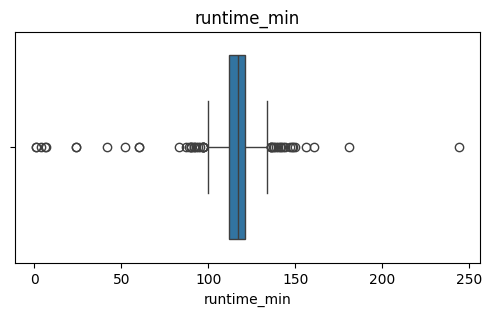

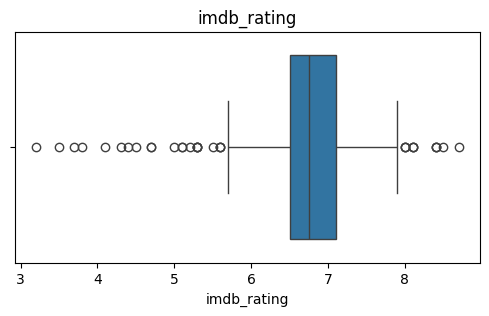

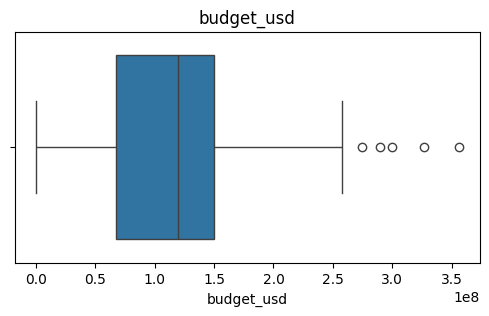

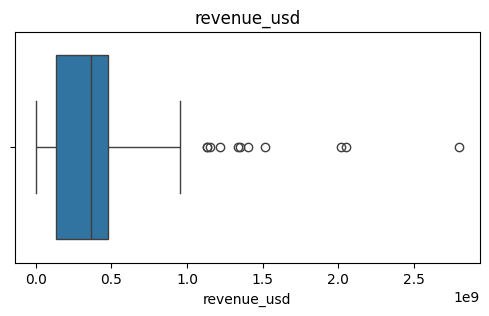

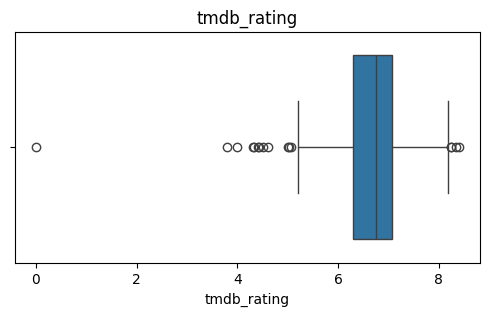

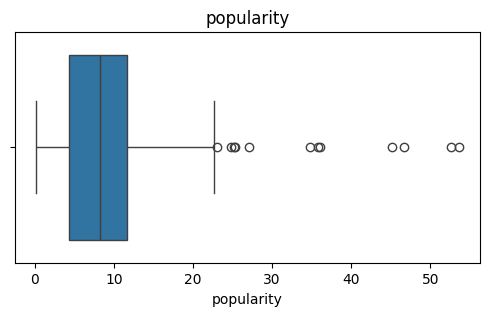

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


cols = [
    'runtime_min',
    'imdb_rating',
    'budget_usd',
    'revenue_usd',
    'tmdb_rating',
    'popularity'
]


for col in cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [ ]:
for col in cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(
        lower,
        upper
    )

In [ ]:
# Label Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in [
    'type',
    'rated',
    'universe',
    'mcu_phase',
    'status'
]:
    df[col] = le.fit_transform(df[col])
# One-Hot Encoding
df = pd.get_dummies(
    df,
    columns=['decade']
)

In [ ]:
# Min-Max Scaling
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[cols] = scaler.fit_transform(
    df[cols]
)
# Standardization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[cols] = scaler.fit_transform(
    df[cols]
)

In [ ]:
# Feature Selection Using Correlation
corr = df.corr(
    numeric_only=True
)

corr['imdb_rating'].sort_values(
    ascending=False
)

,imdb_rating
imdb_rating,1.000000
tmdb_rating,0.789645
runtime_min,0.614898
revenue_usd,0.569442
tmdb_votes,0.560057
popularity,0.537865
box_office_usd,0.514938
year,0.421266
budget_usd,0.366331
decade_2010s,0.352096


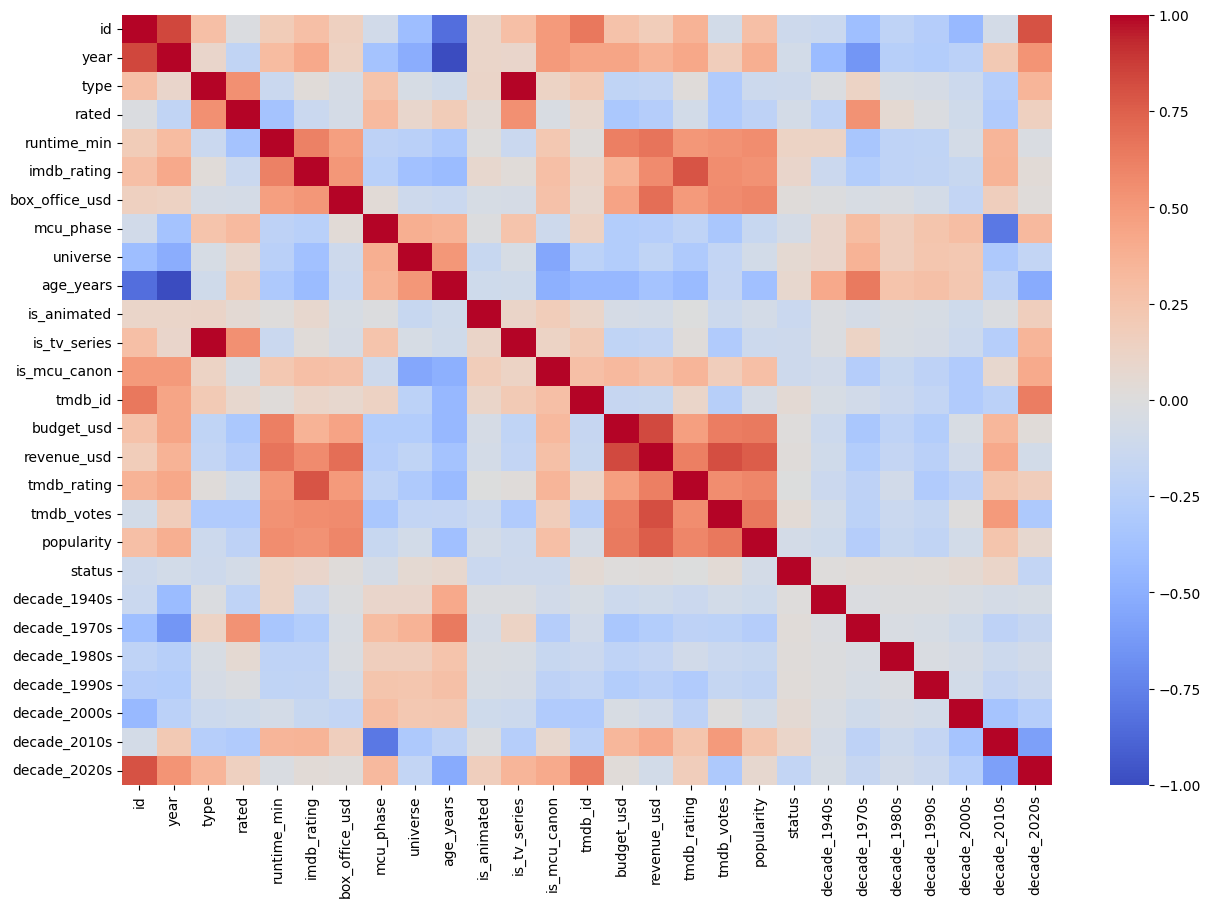

In [ ]:
# Correlation Matrix
corr_matrix = df.corr(
    numeric_only=True
)

corr_matrix
# Heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,10))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm'
)

plt.show()

In [ ]:
# Profit Column
df['profit_usd'] = (
    df['revenue_usd'] -
    df['budget_usd']
)
# Old/New Movie Column
df['old_or_new'] = (
    df['age_years']
    .apply(
        lambda x:
        'Old' if x > 20
        else 'New'
    )
)

In [ ]:
df['imdb_votes'] = (
    df['imdb_votes']
    .astype(str)
    .str.replace(',', '')
)
df['imdb_votes'] = pd.to_numeric(
    df['imdb_votes'],
    errors='coerce'
)
df['imdb_votes'].dtype

dtype('int64')

In [ ]:
df['title'] = (
    df['title']
    .str.strip()
)

df['language'] = (
    df['language']
    .str.title()
)

df['country'] = (
    df['country']
    .str.title()
)

In [ ]:
from sklearn.model_selection import train_test_split


X = df.select_dtypes(
    include='number'
).drop(
    'imdb_rating',
    axis=1
)

y = df['imdb_rating']


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


print(X_train.shape)
print(X_test.shape)

(128, 21)
(33, 21)


In [ ]:
print(
    "Data balancing techniques such as SMOTE are not applicable for regression datasets."
)

Data balancing techniques such as SMOTE are not applicable for regression datasets.


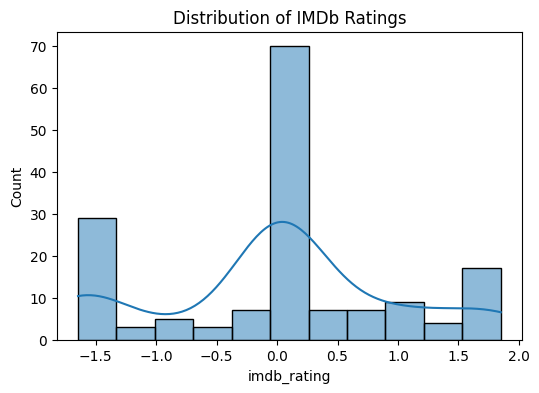

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.histplot(
    df['imdb_rating'],
    kde=True
)

plt.title(
    "Distribution of IMDb Ratings"
)

plt.show()

In [ ]:
print("Original Shape: (161, 50)")
print("Current Shape:", df.shape)

Original Shape: (161, 50)
Current Shape: (161, 53)


In [ ]:
df.to_csv(
    "marvel_master_preprocessed.csv",
    index=False
)

print(
    "Dataset saved successfully!"
)

Dataset saved successfully!


In [ ]:
from google.colab import files

files.download(
    "marvel_master_preprocessed.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print("""
1. Loaded the dataset.
2. Checked dataset information.
3. Displayed sample records.
4. Handled missing values.
5. Removed duplicate records.
6. Detected outliers.
7. Handled outliers.
8. Encoded categorical variables.
9. Performed feature scaling.
10. Selected important features.
11. Generated correlation matrix and heatmap.
12. Performed feature engineering.
13. Converted data types.
14. Cleaned inconsistent data.
15. Split the dataset.
16. Checked data balancing requirements.
17. Visualized data distributions.
18. Compared the dataset before and after preprocessing.
19. Saved the preprocessed dataset.
""")


1. Loaded the dataset.
2. Checked dataset information.
3. Displayed sample records.
4. Handled missing values.
5. Removed duplicate records.
6. Detected outliers.
7. Handled outliers.
8. Encoded categorical variables.
9. Performed feature scaling.
10. Selected important features.
11. Generated correlation matrix and heatmap.
12. Performed feature engineering.
13. Converted data types.
14. Cleaned inconsistent data.
15. Split the dataset.
16. Checked data balancing requirements.
17. Visualized data distributions.
18. Compared the dataset before and after preprocessing.
19. Saved the preprocessed dataset.

